In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After running this, click the link, sign in to your Google account,
# copy the code it gives you, paste it in the box below, press Enter

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from collections import Counter
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")

TensorFlow version: 2.19.0
All libraries loaded successfully!


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/waste_project/dataset/dataset-resized"

# Check if the path is correct — it should print 6 folder names
print("Folders found:", os.listdir(DATASET_PATH))

Folders found: ['plastic', 'glass', 'metal', 'cardboard', 'trash', '.DS_Store', 'paper']


In [ ]:
# ── All settings live here. Change these if needed ──────────────
CLASS_NAMES  = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
IMG_SIZE     = (224, 224)   # MobileNetV2 expects 224x224
BATCH_SIZE   = 32
RANDOM_SEED  = 42
NUM_CLASSES  = len(CLASS_NAMES)

# Maps class name → number  (cardboard=0, glass=1, ... trash=5)
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

print("Classes:", CLASS_NAMES)
print("Image size:", IMG_SIZE)
print("Num classes:", NUM_CLASSES)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Image size: (224, 224)
Num classes: 6


In [ ]:
def load_dataset(dataset_path):
    images = []
    labels = []

    print("Loading images...\n")

    for class_name in CLASS_NAMES:
        class_folder = os.path.join(dataset_path, class_name)

        # Get all image files in this folder
        files = [f for f in os.listdir(class_folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        count = 0
        for filename in files:
            img_path = os.path.join(class_folder, filename)

            # Read image with OpenCV
            img = cv2.imread(img_path)

            if img is None:   # skip if image is corrupted
                continue

            # Convert BGR (OpenCV default) → RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize to 224x224
            img = cv2.resize(img, IMG_SIZE)

            images.append(img)
            labels.append(CLASS_TO_IDX[class_name])
            count += 1

        print(f"  {class_name:12s} → {count} images loaded")

    # Convert to numpy arrays
    images = np.array(images, dtype='float32')
    labels = np.array(labels)

    # Normalize pixel values from [0, 255] → [0, 1]
    # This helps the model learn faster and more stably


    print(f"\nTotal images: {len(images)}")
    print(f"Image array shape: {images.shape}")   # should be (2527, 224, 224, 3)
    print(f"Labels array shape: {labels.shape}")  # should be (2527,)

    return images, labels

images, labels = load_dataset(DATASET_PATH)

Loading images...

  cardboard    → 403 images loaded
  glass        → 501 images loaded
  metal        → 410 images loaded
  paper        → 594 images loaded
  plastic      → 482 images loaded
  trash        → 137 images loaded

Total images: 2527
Image array shape: (2527, 224, 224, 3)
Labels array shape: (2527,)


In [ ]:
print("=" * 40)
print("  DATASET SUMMARY")
print("=" * 40)
print(f"  Total images   : {len(images)}")
print(f"  Image shape    : {images[0].shape}")
print(f"  Pixel min/max  : {images.min():.2f} / {images.max():.2f}")
print(f"  Number of classes: {NUM_CLASSES}")
print("-" * 40)

counts = Counter(labels)
for i, name in enumerate(CLASS_NAMES):
    pct = counts[i] / len(labels) * 100
    bar = "█" * int(pct / 2)
    print(f"  {name:12s}: {counts[i]:4d}  ({pct:.1f}%)  {bar}")

print("=" * 40)

  DATASET SUMMARY
  Total images   : 2527
  Image shape    : (224, 224, 3)
  Pixel min/max  : 0.00 / 255.00
  Number of classes: 6
----------------------------------------
  cardboard   :  403  (15.9%)  ███████
  glass       :  501  (19.8%)  █████████
  metal       :  410  (16.2%)  ████████
  paper       :  594  (23.5%)  ███████████
  plastic     :  482  (19.1%)  █████████
  trash       :  137  (5.4%)  ██


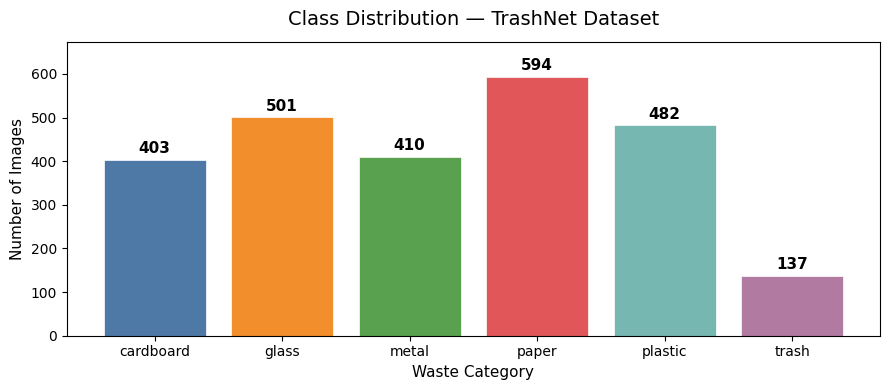

Chart saved to Drive!


In [ ]:
counts = Counter(labels)
names  = CLASS_NAMES
values = [counts[i] for i in range(NUM_CLASSES)]

plt.figure(figsize=(9, 4))
colors = ['#4e79a7','#f28e2b','#59a14f','#e15759','#76b7b2','#b07aa1']
bars = plt.bar(names, values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Class Distribution — TrashNet Dataset', fontsize=14, pad=12)
plt.xlabel('Waste Category', fontsize=11)
plt.ylabel('Number of Images', fontsize=11)
plt.ylim(0, max(values) + 80)
plt.tight_layout()

# Save to Drive
save_path = "/content/drive/MyDrive/waste_project/class_distribution.png"
plt.savefig(save_path, dpi=150)
plt.show()
print("Chart saved to Drive!")

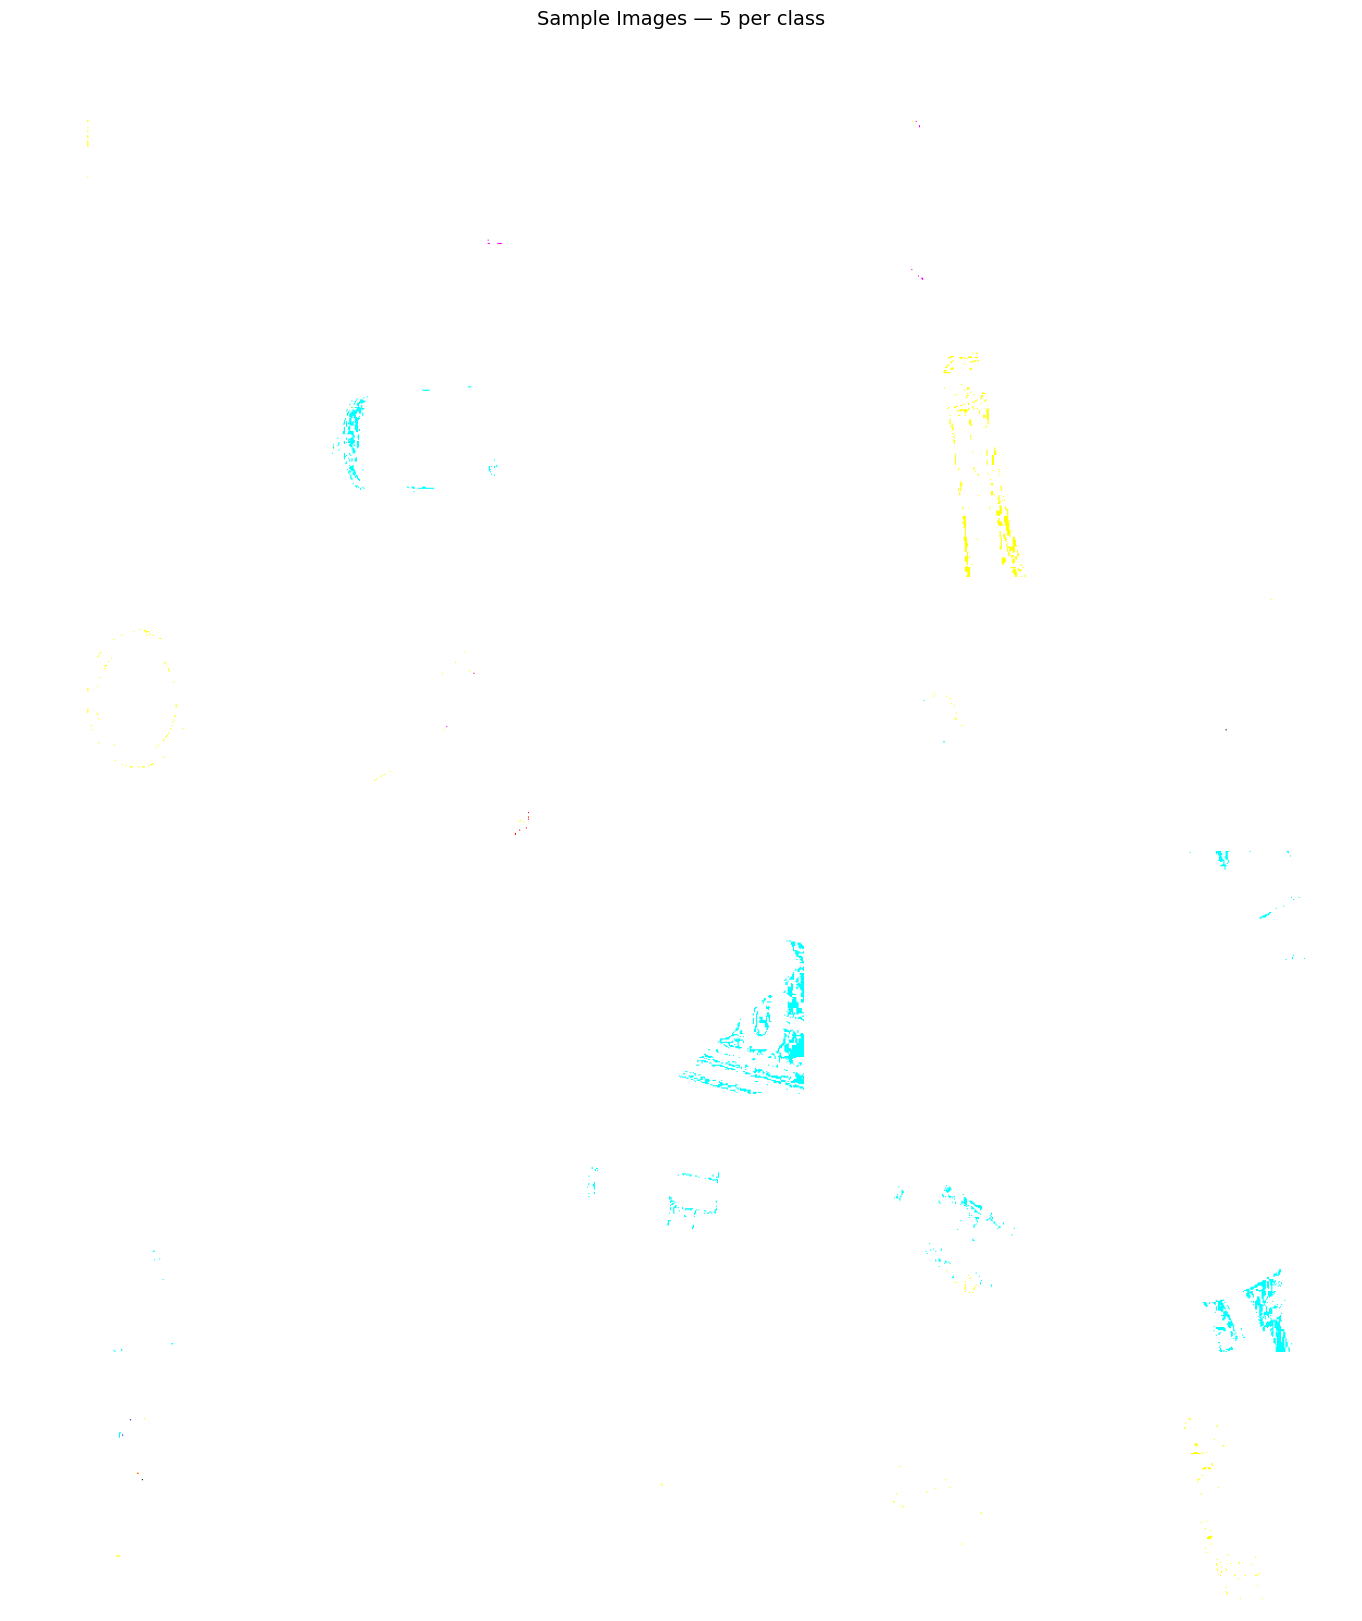

Sample images saved to Drive!


In [ ]:
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(14, 16))
fig.suptitle('Sample Images — 5 per class', fontsize=14, y=1.01)

for row, class_idx in enumerate(range(NUM_CLASSES)):
    # Get images belonging to this class
    class_images = images[labels == class_idx]

    for col in range(5):
        ax = axes[row][col]
        ax.imshow(class_images[col])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(CLASS_NAMES[class_idx], fontsize=11,
                          rotation=0, labelpad=60, va='center')

plt.tight_layout()

save_path = "/content/drive/MyDrive/waste_project/sample_images.png"
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print("Sample images saved to Drive!")

In [ ]:
# Step 1: Split off 10% as test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    images, labels,
    test_size=0.10,
    stratify=labels,       # ensures each split has same class %
    random_state=RANDOM_SEED
)

# Step 2: From remaining 90%, split 20% as validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.20,        # 20% of 90% = ~18% of total
    stratify=y_train_val,
    random_state=RANDOM_SEED
)

print("Dataset split complete!")
print(f"  Train      : {len(X_train)} images  ({len(X_train)/len(images)*100:.0f}%)")
print(f"  Validation : {len(X_val)} images  ({len(X_val)/len(images)*100:.0f}%)")
print(f"  Test       : {len(X_test)} images  ({len(X_test)/len(images)*100:.0f}%)")

# Verify class balance in each split
print("\nClass balance check (train):")
train_counts = Counter(y_train)
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:12s}: {train_counts[i]}")

Dataset split complete!
  Train      : 1819 images  (72%)
  Validation : 455 images  (18%)
  Test       : 253 images  (10%)

Class balance check (train):
  cardboard   : 290
  glass       : 361
  metal       : 295
  paper       : 427
  plastic     : 347
  trash       : 99


In [ ]:
# Augmentation = artificially creating more training images by
# flipping, rotating, zooming the existing ones.
# This helps prevent overfitting (memorizing instead of learning)

train_datagen = ImageDataGenerator(
    rotation_range=20,          # rotate image up to 20 degrees
    width_shift_range=0.1,      # shift left/right by 10%
    height_shift_range=0.1,     # shift up/down by 10%
    horizontal_flip=True,       # randomly mirror the image
    zoom_range=0.15,            # zoom in/out by 15%
    brightness_range=[0.8, 1.2] # vary brightness slightly
)

# Validation gets NO augmentation — we want real unmodified images
val_datagen = ImageDataGenerator()

# Convert labels to one-hot: 2 → [0,0,1,0,0,0]  (for 6 classes)
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

# Create generators
train_gen = train_datagen.flow(X_train, y_train_cat,
                                batch_size=BATCH_SIZE, shuffle=True)
val_gen   = val_datagen.flow(X_val, y_val_cat,
                              batch_size=BATCH_SIZE, shuffle=False)

print("Augmentation generators ready!")
print(f"Steps per epoch (train): {len(X_train) // BATCH_SIZE}")
print(f"Steps per epoch (val)  : {len(X_val) // BATCH_SIZE}")

Augmentation generators ready!
Steps per epoch (train): 56
Steps per epoch (val)  : 14


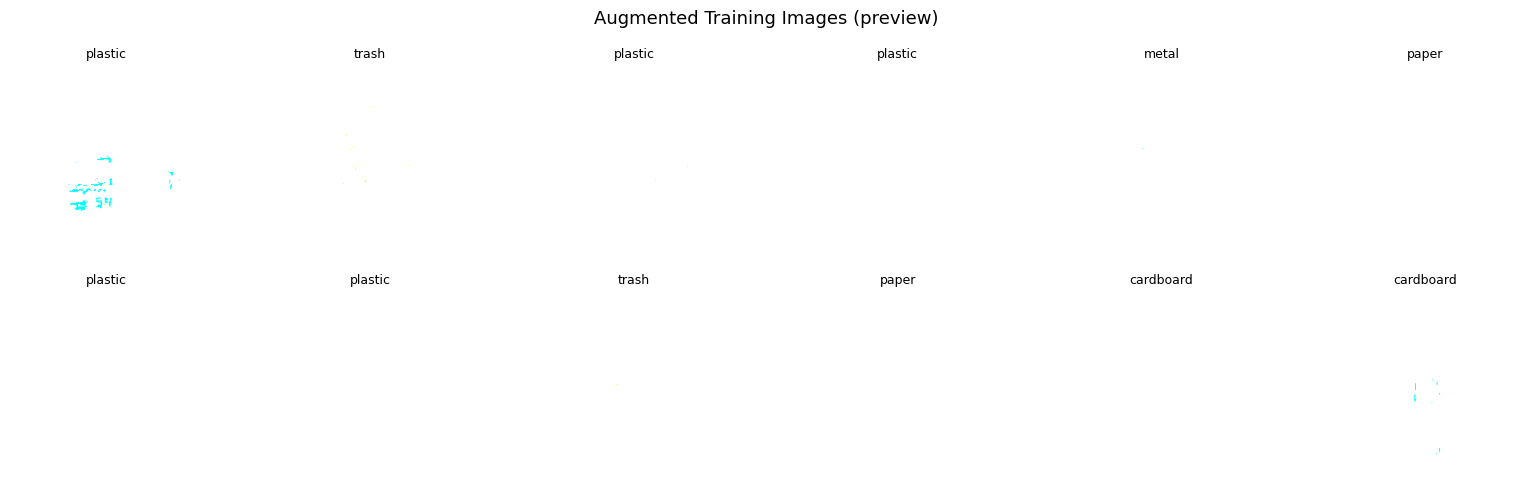

These are the kinds of images your model will train on!


In [ ]:
# Let's see what augmented images look like
sample_imgs, sample_labels = next(train_gen)

fig, axes = plt.subplots(2, 6, figsize=(16, 5))
fig.suptitle('Augmented Training Images (preview)', fontsize=13)

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    ax.axis('off')
    class_idx = sample_labels[i].argmax()
    ax.set_title(CLASS_NAMES[class_idx], fontsize=9)

plt.tight_layout()
plt.show()
print("These are the kinds of images your model will train on!")

In [ ]:
# Save the split data so Part 2 (training) can load it directly
# without re-running everything

save_dir = "/content/drive/MyDrive/waste_project/"

np.save(save_dir + "X_train.npy", X_train)
np.save(save_dir + "X_val.npy",   X_val)
np.save(save_dir + "X_test.npy",  X_test)
np.save(save_dir + "y_train.npy", y_train)
np.save(save_dir + "y_val.npy",   y_val)
np.save(save_dir + "y_test.npy",  y_test)

print("All data saved to Drive!")
print("\nFiles saved:")
for f in os.listdir(save_dir):
    if f.endswith('.npy'):
        size_mb = os.path.getsize(save_dir + f) / (1024*1024)
        print(f"  {f:20s}  {size_mb:.1f} MB")


All data saved to Drive!

Files saved:
  X_train.npy           1044.5 MB
  X_val.npy             261.3 MB
  X_test.npy            145.3 MB
  y_train.npy           0.0 MB
  y_val.npy             0.0 MB
  y_test.npy            0.0 MB
